## Exploratory Data Analysis

In [31]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import ks_2samp

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import roc_auc_score

from src.evaluation import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [32]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

In [33]:
y_train.value_counts()

y
0    2512
1    2488
Name: count, dtype: int64

In [34]:
x_train.isna().values.any()

False

Balanced dataset with no missing values

### Feature Importance

In [35]:
scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [36]:
def calculate_feature_importance(x_train_scaled, y_train):

    # Mutual Information
    mi_scores = mutual_info_classif(x_train_scaled, y_train, random_state=42)
    mi_scores = pd.Series(mi_scores, index=x_train_scaled.columns)
    mi_rank = mi_scores.rank(ascending=False, method="min")


    # ANOVA F-score
    f_scores, p_values = f_classif(x_train_scaled, y_train)
    f_scores = pd.Series(f_scores, index=x_train_scaled.columns)
    f_rank = f_scores.rank(ascending=False, method="min")


    # AUC-ROC Scores
    auc_scores = {}

    for col in x_train_scaled.columns:
        auc = roc_auc_score(y_train, x_train_scaled[col])
        auc = max(auc, 1 - auc)
        auc_scores[col] = auc

    auc_scores = pd.Series(auc_scores)
    auc_rank = auc_scores.rank(ascending=False, method="min")


    # KOLMOGOROV-SMIRNOV (KS) TEST
    ks_scores = {}

    for col in x_train_scaled.columns:

        class_0 = x_train_scaled.loc[y_train == 0, col]
        class_1 = x_train_scaled.loc[y_train == 1, col]

        stat, p_value = ks_2samp(class_0, class_1)
        ks_scores[col] = stat

    ks_scores = pd.Series(ks_scores)
    ks_rank = ks_scores.rank(ascending=False, method="min")


    # Logistic Regression L1
    l1 = LogisticRegression(penalty="l1", solver="saga", max_iter=10_000)

    l1.fit(x_train_scaled, y_train)
    l1_scores = np.abs(l1.coef_[0])
    l1_scores = pd.Series(l1_scores, index=x_train.columns)
    l1_rank = l1_scores.rank(ascending=False)


    # Tree-based importance
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    rf.fit(x_train_scaled, y_train)
    rf_scores = pd.Series(rf.feature_importances_, index=x_train.columns)
    rf_rank = rf_scores.rank(ascending=False)


    # ===================
    # RESULTS TABLE 
    # ===================

    results = pd.DataFrame({
        "feature": x_train_scaled.columns,

        "mutual_info": mi_scores,
        "f_score": f_scores,
        "auc_roc": auc_scores,
        "ks_stat": ks_scores,
        "l1": l1_scores,
        "rf": rf_scores,

        "mi_rank": mi_rank,
        "f_rank": f_rank,
        "auc_roc_rank": auc_rank,
        "ks_stat_rank": ks_rank,
        "l1_rank": l1_rank,
        "rf_rank": rf_rank,

    }).reset_index(drop=True)

    return results

results = calculate_feature_importance(x_train_scaled, y_train)

In [25]:
rank_columns = [
    "mi_rank",
    "f_rank",
    "auc_roc_rank",
    "ks_stat_rank",
    "l1_rank",
    "rf_rank",
]

metric_columns = [
    "mutual_info",
    "f_score",
    "auc_roc",
    "ks_stat",
    "l1",
    "rf",
]

In [26]:
def calculate_normalized_rank(results, rank_columns):

    n_features = len(results)

    for col in rank_columns:
        results[col + "_norm"] = (results[col] - 1) / (n_features - 1)

    norm_rank_cols = [c + "_norm" for c in rank_columns]
    results["avg_normalized_rank"] = (results[norm_rank_cols].mean(axis=1))


    # lower = better
    results = results.sort_values(by="avg_normalized_rank")

    TOP_K = 100
    results["votes_top_k"] = 0

    for col in rank_columns:
        top_features = results.nsmallest(TOP_K, col)["feature"]
        results.loc[results["feature"].isin(top_features), "votes_top_k"] += 1
    
    return results

results = calculate_normalized_rank(results, rank_columns)
print("===== Top 20 features by 'avg_normalized_rank' =====")
display(results.head(n=20))
results.to_csv("../outputs/feature_importance_ranking.csv", index=False)

===== Top 20 features by 'avg_normalized_rank' =====


,feature,mutual_info,f_score,auc_roc,ks_stat,l1,rf,mi_rank,f_rank,auc_roc_rank,ks_stat_rank,l1_rank,rf_rank,mi_rank_norm,f_rank_norm,auc_roc_rank_norm,ks_stat_rank_norm,l1_rank_norm,rf_rank_norm,avg_normalized_rank,votes_top_k
389,V390,0.008511,65.771559,0.555207,0.081085,3.603060,0.005130,76.0,1.0,7.0,16.0,1.0,12.0,0.150301,0.000000,0.012024,0.030060,0.000000,0.022044,0.035738,6
308,V309,0.009498,43.722840,0.553451,0.091623,0.838038,0.002826,64.0,10.0,9.0,9.0,7.0,24.0,0.126253,0.018036,0.016032,0.016032,0.012024,0.046092,0.039078,6
344,V345,0.009262,44.907550,0.547913,0.085407,2.104925,0.003451,68.0,8.0,13.0,13.0,3.0,22.0,0.134269,0.014028,0.024048,0.024048,0.004008,0.042084,0.040414,6
198,V199,0.008195,50.191733,0.551746,0.083627,2.346277,0.004915,79.0,7.0,11.0,14.0,2.0,15.0,0.156313,0.012024,0.020040,0.026052,0.002004,0.028056,0.040748,6
31,V32,0.006444,53.937593,0.558361,0.087775,1.197728,0.004429,108.0,4.0,3.0,10.0,4.5,18.0,0.214429,0.006012,0.004008,0.018036,0.007014,0.034068,0.047261,5
174,V175,0.006444,53.937593,0.558361,0.087775,1.197728,0.003743,108.0,4.0,3.0,10.0,4.5,20.0,0.214429,0.006012,0.004008,0.018036,0.007014,0.038076,0.047929,5
463,V464,0.012494,7.930038,0.524538,0.053097,0.567164,0.002191,32.0,22.0,21.0,29.0,8.0,41.0,0.062124,0.042084,0.040080,0.056112,0.014028,0.080160,0.049098,6
264,V265,0.015911,37.632162,0.552773,0.107549,0.153257,0.005396,16.0,12.0,10.0,4.0,168.0,10.0,0.030060,0.022044,0.018036,0.006012,0.334669,0.018036,0.071476,5
255,V256,0.009380,5.962121,0.516043,0.043255,0.437392,0.002109,65.0,26.0,39.0,37.0,16.0,61.0,0.128257,0.050100,0.076152,0.072144,0.030060,0.120240,0.079492,6
376,V377,0.013432,3.871382,0.515868,0.043800,0.215082,0.002410,23.0,37.0,40.0,36.0,92.0,28.0,0.044088,0.072144,0.078156,0.070140,0.182365,0.054108,0.083500,6


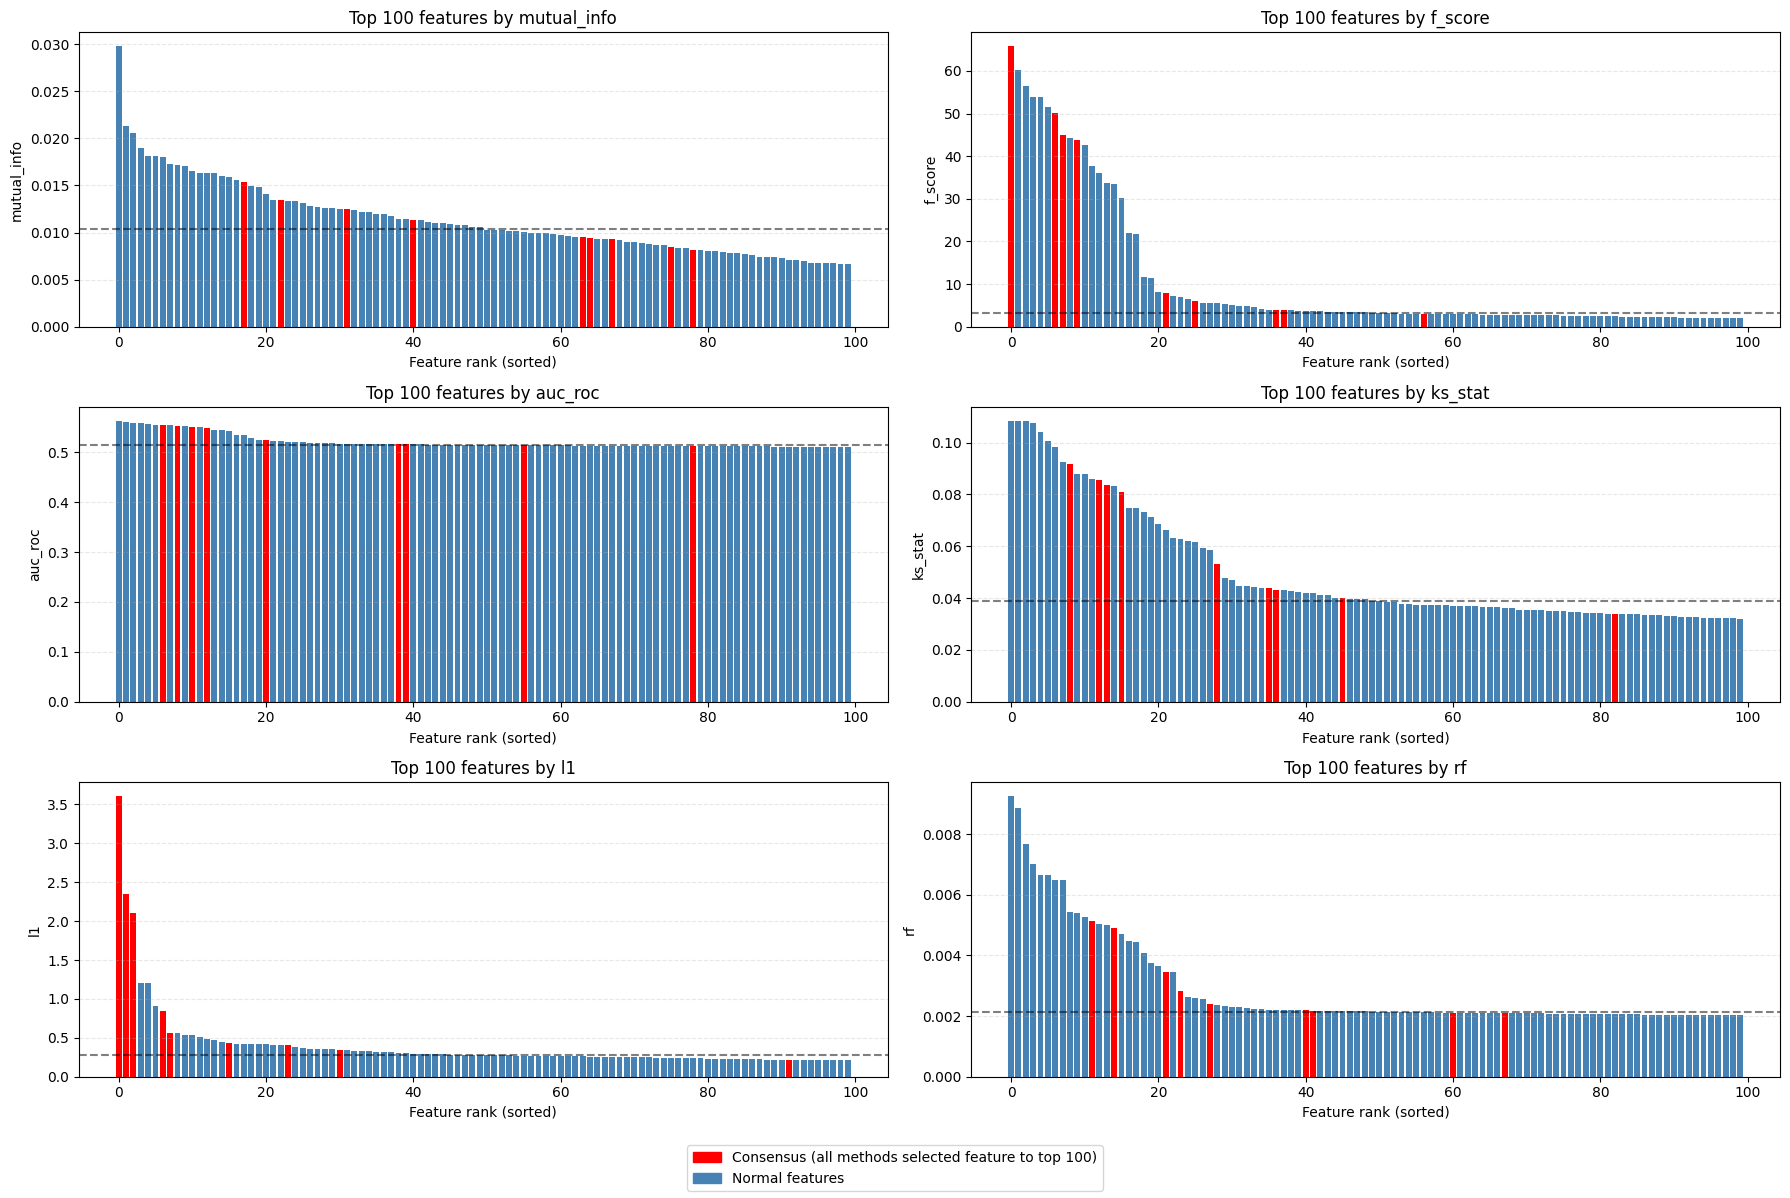

In [30]:
TOP_N = 100

metrics = metric_columns
consensus_mask = results["votes_top_k"] == len(metrics)

n_cols = 2
n_rows = int(np.ceil(len(metrics) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(metrics):

    df = results.sort_values(by=col, ascending=False).head(TOP_N)
    colors = np.where(df["votes_top_k"] == len(metrics), "red", "steelblue")

    axes[i].bar(range(len(df)), df[col], color=colors)

    axes[i].set_title(f"Top {TOP_N} features by {col}")
    axes[i].set_xlabel("Feature rank (sorted)")
    axes[i].set_ylabel(col)

    axes[i].axhline(df[col].median(), linestyle="--", color="black", alpha=0.5)
    axes[i].grid(True, linestyle="--", alpha=0.3, axis="y")

red_patch = mpatches.Patch(color='red', label='Consensus (all methods selected feature to top 100)')
blue_patch = mpatches.Patch(color='steelblue', label='Normal features')

fig.legend(
    handles=[red_patch, blue_patch],
    loc='lower center'
)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

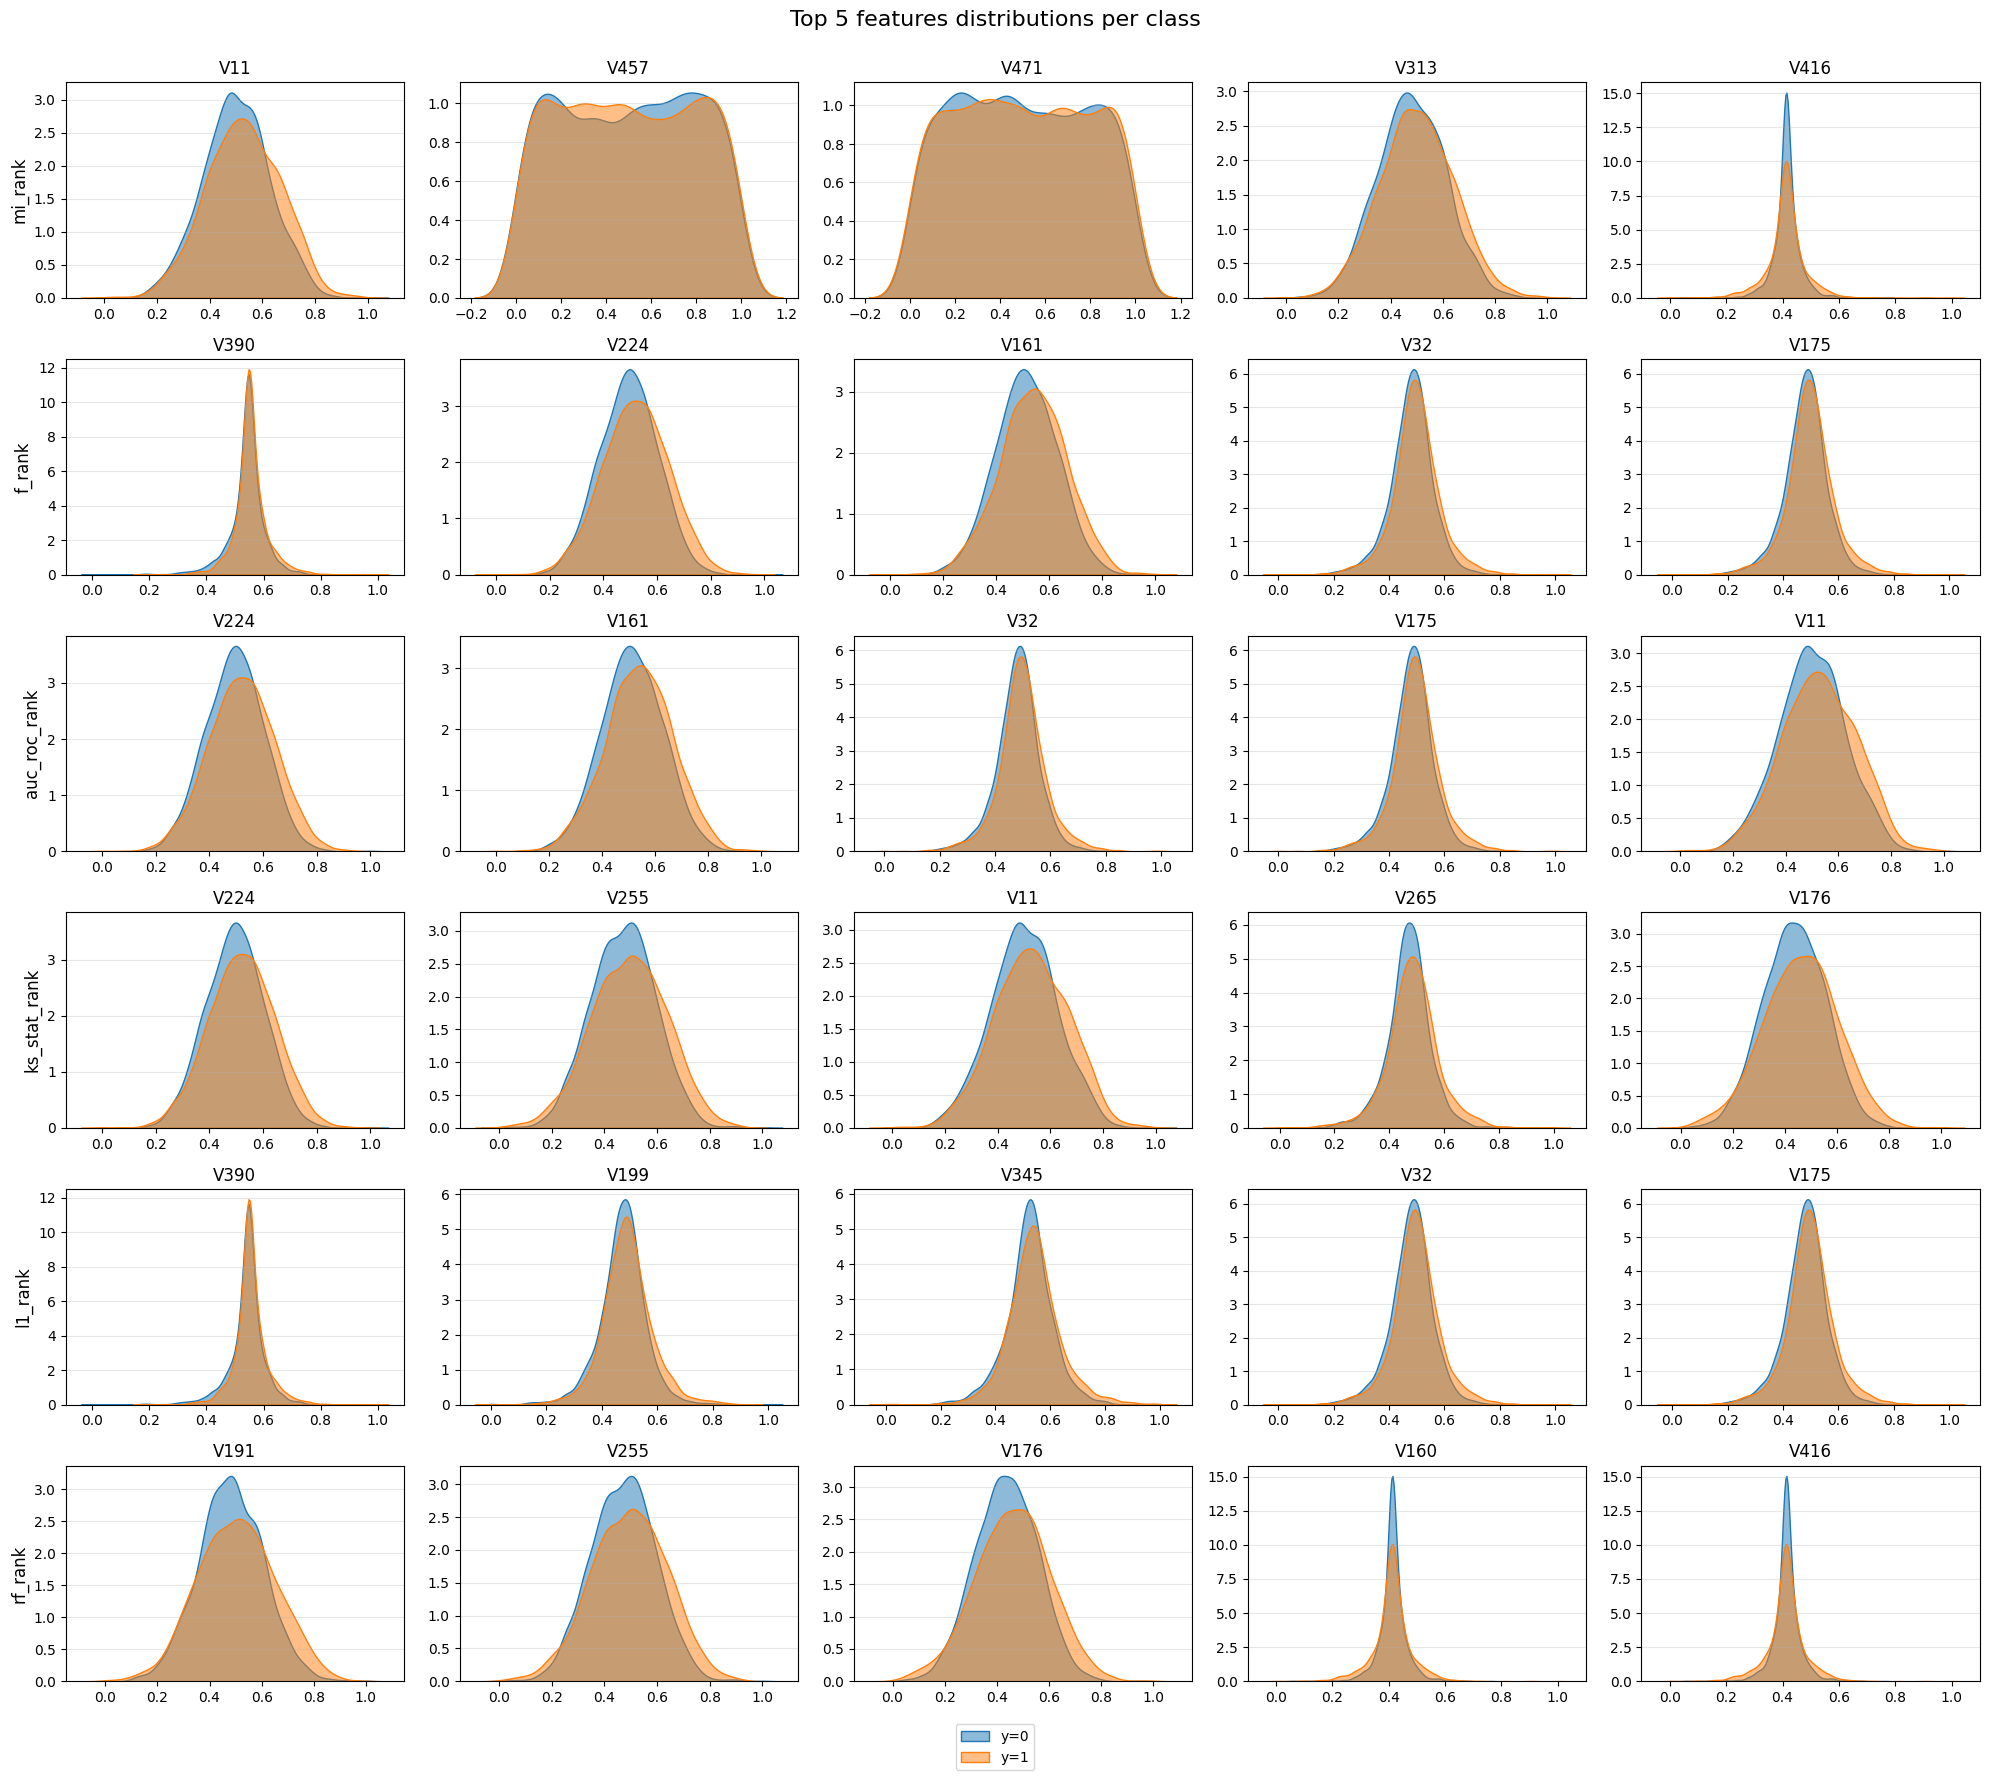

In [18]:
TOP_K = 5

n_rows = len(rank_columns)
n_cols = TOP_K

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for row_idx, rank_col in enumerate(rank_columns):

    top_features = (results.sort_values(rank_col).head(TOP_K)["feature"].values)

    for col_idx, feature in enumerate(top_features):

        ax = axes[row_idx, col_idx]

        # class 0
        sns.kdeplot(
            x=x_train_scaled.loc[y_train == 0, feature],
            ax=ax,
            label="y=0",
            fill=True,
            alpha=0.5,
        )

        # class 1
        sns.kdeplot(
            x=x_train_scaled.loc[y_train == 1, feature],
            ax=ax,
            label="y=1",
            fill=True,
            alpha=0.5
        )

        ax.set_title(f"{feature}")

        if col_idx == 0:
            ax.set_ylabel(rank_col, fontsize=12)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.grid(True, alpha=0.3, axis="y")

        if not (row_idx == 0 and col_idx == 0):
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center")

plt.suptitle("Top 5 features distributions per class", fontsize=16)
plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()

---